In [1]:
import torch
import geospaNN
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

R callback write-console: Loading required package: BRISC
  
R callback write-console: Loading required package: RANN
  
R callback write-console: Loading required package: parallel
  
R callback write-console: Loading required package: rdist
  
R callback write-console: Loading required package: matrixStats
  
R callback write-console: Loading required package: pbapply
  
R callback write-console: The ordering of inputs x (covariates) and y (response) in BRISC_estimation has been changed BRISC 1.0.0 onwards.
  Please check the new documentation with ?BRISC_estimation.
  


R package: BRISC installed


/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def f1(X): return 10 * np.sin(2*np.pi * X)
p = 1;
funXY = f1

n = 1000
nn = 20

sigma = 1
phi = 0.3
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

# Simulate data
torch.manual_seed(2025)
_, _, _, _, X = geospaNN.Simulation(n, p, nn, funXY, torch.tensor([1, 5, 0.01]), range=[0, 1])
X = X.reshape(-1,p)
X = (X - X.min())/(X.max() - X.min())
torch.manual_seed(2025)
_, _, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 1])
Y = funXY(X).reshape(-1) + corerr

/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_9020/3457030453.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)
/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_9020/3457030453.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2*np.pi * X)


In [3]:
# Preprocess data
data = geospaNN.make_graph(X, Y, coord, nn, Ind_list = None)

torch.manual_seed(2024)
np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn, 
                                                      test_proportion=0.2, val_proportion=0.2)

In [4]:
# Fit SPLMM                                                      
model_linear = geospaNN.model.linear_gls(data_train)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 2 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


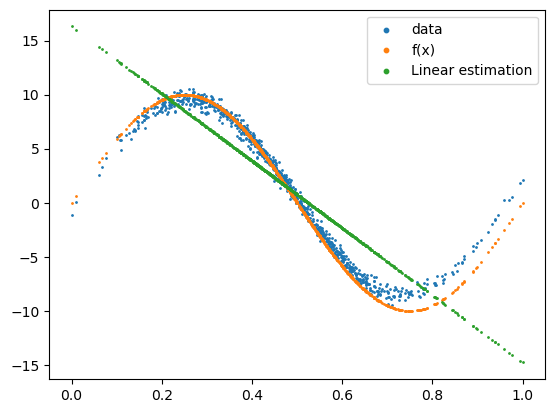

In [5]:
# Estimation and save the figure
estimate = model_linear.estimate(X)
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), estimate, s=1, label='Linear estimation')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'Estimation_linear.png')

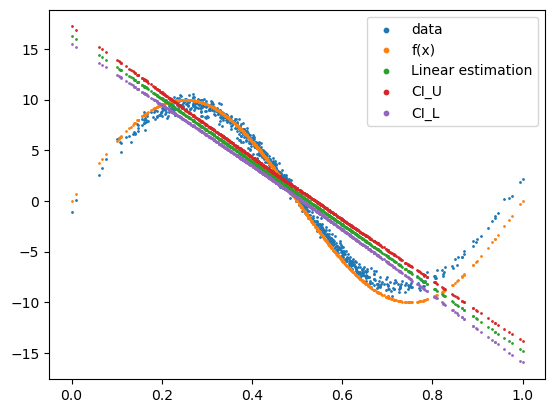

In [6]:
# Confidence interval and save the figure
[CI_U, CI_L] = geospaNN.confidence_interval(model_linear, X, rep = 200, quantiles = [97.5, 2.5])
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), estimate, s=1, label='Linear estimation')
plt.scatter(X.detach().numpy(), CI_U, s=1, label='CI_U')
plt.scatter(X.detach().numpy(), CI_L, s=1, label='CI_L')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + "Prediction_linear_CI.png")

/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/geospaNN/model.py:349: UserWarning: Please use argument PI instead of CI to indicate whether to create prediction interval.
  warnings.warn("Please use argument PI instead of CI to indicate whether to create prediction interval.")
/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/geospaNN/utils.py:489: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1780240406875/work/aten/src/ATen/native/TensorShape.cpp:4483.)
  w_test[i] = torch.dot(bi.T, w_train[ind]).squeeze()


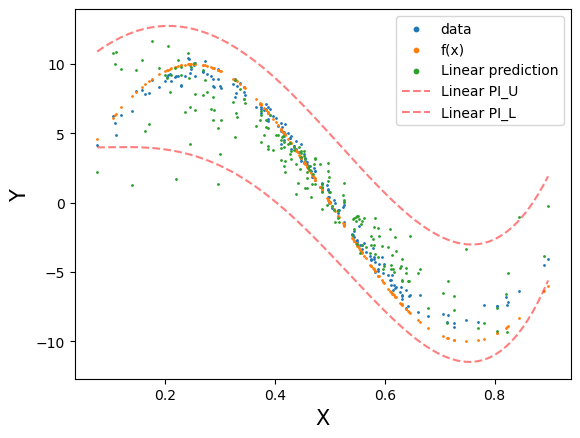

In [7]:
[test_predict, test_PI_U, test_PI_L] = model_linear.predict(data_train, data_test, PI = True)

x_np = data_test.x.detach().numpy().reshape(-1)
x_smooth = np.linspace(x_np.min(), x_np.max(), 200)  # Create finer x-points
degree = 4
U_fit = np.polyfit(x_np, test_PI_U, degree)
L_fit = np.polyfit(x_np, test_PI_L, degree)
Pred_fit = np.polyfit(x_np, test_predict, degree)
y_smooth_U = np.polyval(U_fit, x_smooth)
y_smooth_L = np.polyval(L_fit, x_smooth)
y_smooth = np.polyval(Pred_fit, x_smooth)

plt.clf()
plt.scatter(data_test.x.detach().numpy(), data_test.y.detach().numpy(), s=1, label='data')
plt.scatter(data_test.x.detach().numpy(), funXY(data_test.x.detach().numpy()), s=1,label='f(x)')
plt.scatter(data_test.x.detach().numpy(), test_predict.detach().numpy(), s=1, label='Linear prediction')
plt.plot(x_smooth, y_smooth_U, linestyle='--', label='Linear PI_U', color = 'red', alpha = 0.5)
plt.plot(x_smooth, y_smooth_L, linestyle='--', label='Linear PI_L', color = 'red', alpha = 0.5)
plt.xlabel("X", fontsize=15)
plt.ylabel("Y", fontsize=15)
lgnd = plt.legend()
for handle in lgnd.legend_handles[:3]:
    handle.set_sizes([10.0])
plt.savefig(path + "Prediction_linear.png")

In [8]:
import pandas as pd

data = torch.concatenate([data_train.x, data_train.y.reshape(-1,1), data_train.pos], axis = 1)
df = pd.DataFrame(data)
df.to_csv(path+"tensor.csv", index=False)